# UMAP Analysis of Front Properties

In [2]:
# imports
import os

import numpy as np
import pandas

from sklearn.preprocessing import StandardScaler
import umap

from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns

from ocpy.utils import plotting

/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load front properties

In [3]:
group_path = os.path.join(os.getenv('OS_OGCM'), 'LLC', 'Fronts', 'group_fronts', 'v1')
group_tbl_file = os.path.join(group_path, 'front_properties_20121109T12_00_00_v1_bin_A.parquet')

gtbl = pandas.read_parquet(group_tbl_file)
print(f"Loaded {len(gtbl)} fronts with {len(gtbl.columns)} columns")
gtbl.head()

Loaded 135654 fronts with 156 columns


,flabel,npix,coriolis_f_mean,coriolis_f_std,coriolis_f_median,coriolis_f_p10,coriolis_f_p25,coriolis_f_p75,coriolis_f_p90,divergence_mean,...,V_p25,V_p75,V_p90,W_mean,W_std,W_median,W_p10,W_p25,W_p75,W_p90
0,1,13,-0.000143,1.884019e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,-5.427167e-06,...,-0.013987,0.009299,0.016614,7.924541e-07,9.985207e-08,7.693138e-07,6.842287e-07,7.159358e-07,8.615179e-07,9.433354e-07
1,2,20,-0.000143,2.018708e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,1.051717e-06,...,0.005101,0.016774,0.021964,8.096799e-07,1.318373e-07,8.290738e-07,5.839551e-07,7.413350e-07,9.165659e-07,9.565037e-07
2,3,28,-0.000143,2.317883e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,-3.063451e-06,...,-0.022933,0.007288,0.012676,6.156698e-07,5.224361e-07,6.213918e-07,3.224615e-07,5.065449e-07,8.346864e-07,1.086146e-06
3,4,128,-0.000143,4.652389e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,-3.053880e-06,...,-0.021386,0.005936,0.019350,1.090969e-06,2.234595e-07,1.138286e-06,8.068491e-07,9.786987e-07,1.241225e-06,1.315759e-06
4,5,27,-0.000143,2.268354e-08,-0.000143,-0.000143,-0.000143,-0.000143,-0.000143,6.311122e-07,...,-0.011144,0.009972,0.019935,9.696325e-07,2.713012e-07,9.236500e-07,8.131438e-07,8.650712e-07,1.065129e-06,1.260055e-06


# Feature engineering

In [12]:
# Build feature DataFrame
features = pandas.DataFrame({
    'flabel': gtbl['flabel'],
    'npix': gtbl['npix'],
    'strain_over_f': gtbl['strain_mag_median'] / np.abs(gtbl['coriolis_f_median']),
    'divergence_over_f': gtbl['divergence_median'] / np.abs(gtbl['coriolis_f_median']),
    'gradb2_median': np.log10(gtbl['gradb2_median']),
    'frontogenesis_tendency_median': gtbl['frontogenesis_tendency_median'],
})

# Drop rows with NaN or Inf
#feature_cols = ['npix', 'strain_over_f', 'divergence_over_f',
feature_cols = ['strain_over_f', 'divergence_over_f',
                'gradb2_median', 'frontogenesis_tendency_median']
features = features.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols)
print(f"{len(features)} fronts after dropping NaN/Inf (removed {len(gtbl) - len(features)})")

135654 fronts after dropping NaN/Inf (removed 0)


# Normalize to zero-mean, unit variance

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols].values)
print("Feature means (should be ~0):", X_scaled.mean(axis=0).round(6))
print("Feature stds  (should be ~1):", X_scaled.std(axis=0).round(6))

Feature means (should be ~0): [ 0.  0.  0. -0.]
Feature stds  (should be ~1): [1. 1. 1. 1.]


# UMAP

In [14]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                    metric='euclidean', random_state=42)
embedding = reducer.fit_transform(X_scaled)
print(f"UMAP embedding shape: {embedding.shape}")

/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (135654, 2)


# Save to parquet

In [15]:
umap_tbl = pandas.DataFrame({
    'flabel': features['flabel'].values,
    'UMAP_0': embedding[:, 0],
    'UMAP_1': embedding[:, 1],
})

outfile = os.path.join(group_path, 'front_properties_umap_20121109T12_00_00_v1_bin_A.parquet')
umap_tbl.to_parquet(outfile, index=False)
print(f"Saved UMAP results to {outfile}")
umap_tbl.head()

Saved UMAP results to /home/xavier/Projects/Oceanography/data/OGCM/LLC/Fronts/group_fronts/v1/front_properties_umap_20121109T12_00_00_v1_bin_A.parquet


,flabel,UMAP_0,UMAP_1
0,1,9.898259,-1.580726
1,2,5.565212,-4.094326
2,3,9.105026,-2.481805
3,4,16.288847,2.047907
4,5,9.833923,-4.601441


# Visualizations

## Basic scatter

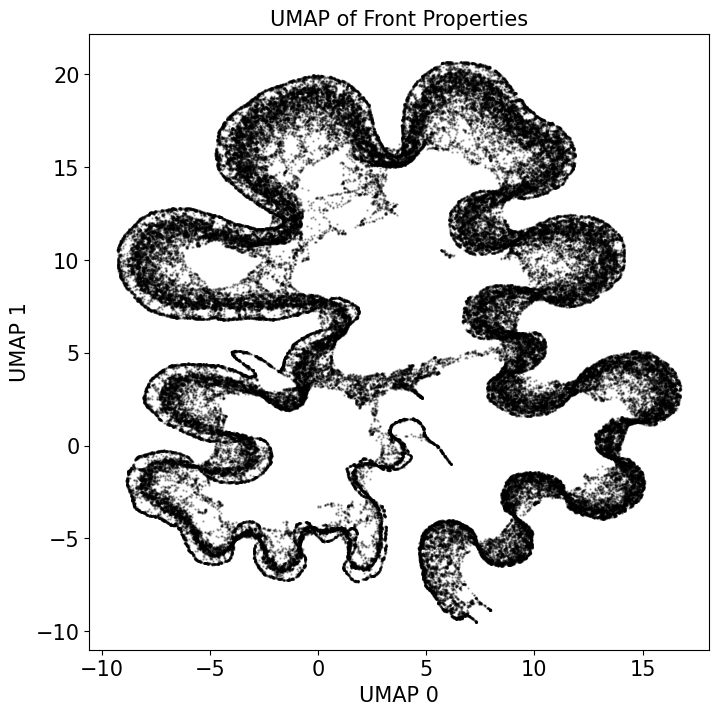

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(embedding[:, 0], embedding[:, 1], s=0.5, alpha=0.3, c='k')
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.set_title('UMAP of Front Properties')
plotting.set_fontsize(ax, 15.)
plt.show()

## Colored by input features

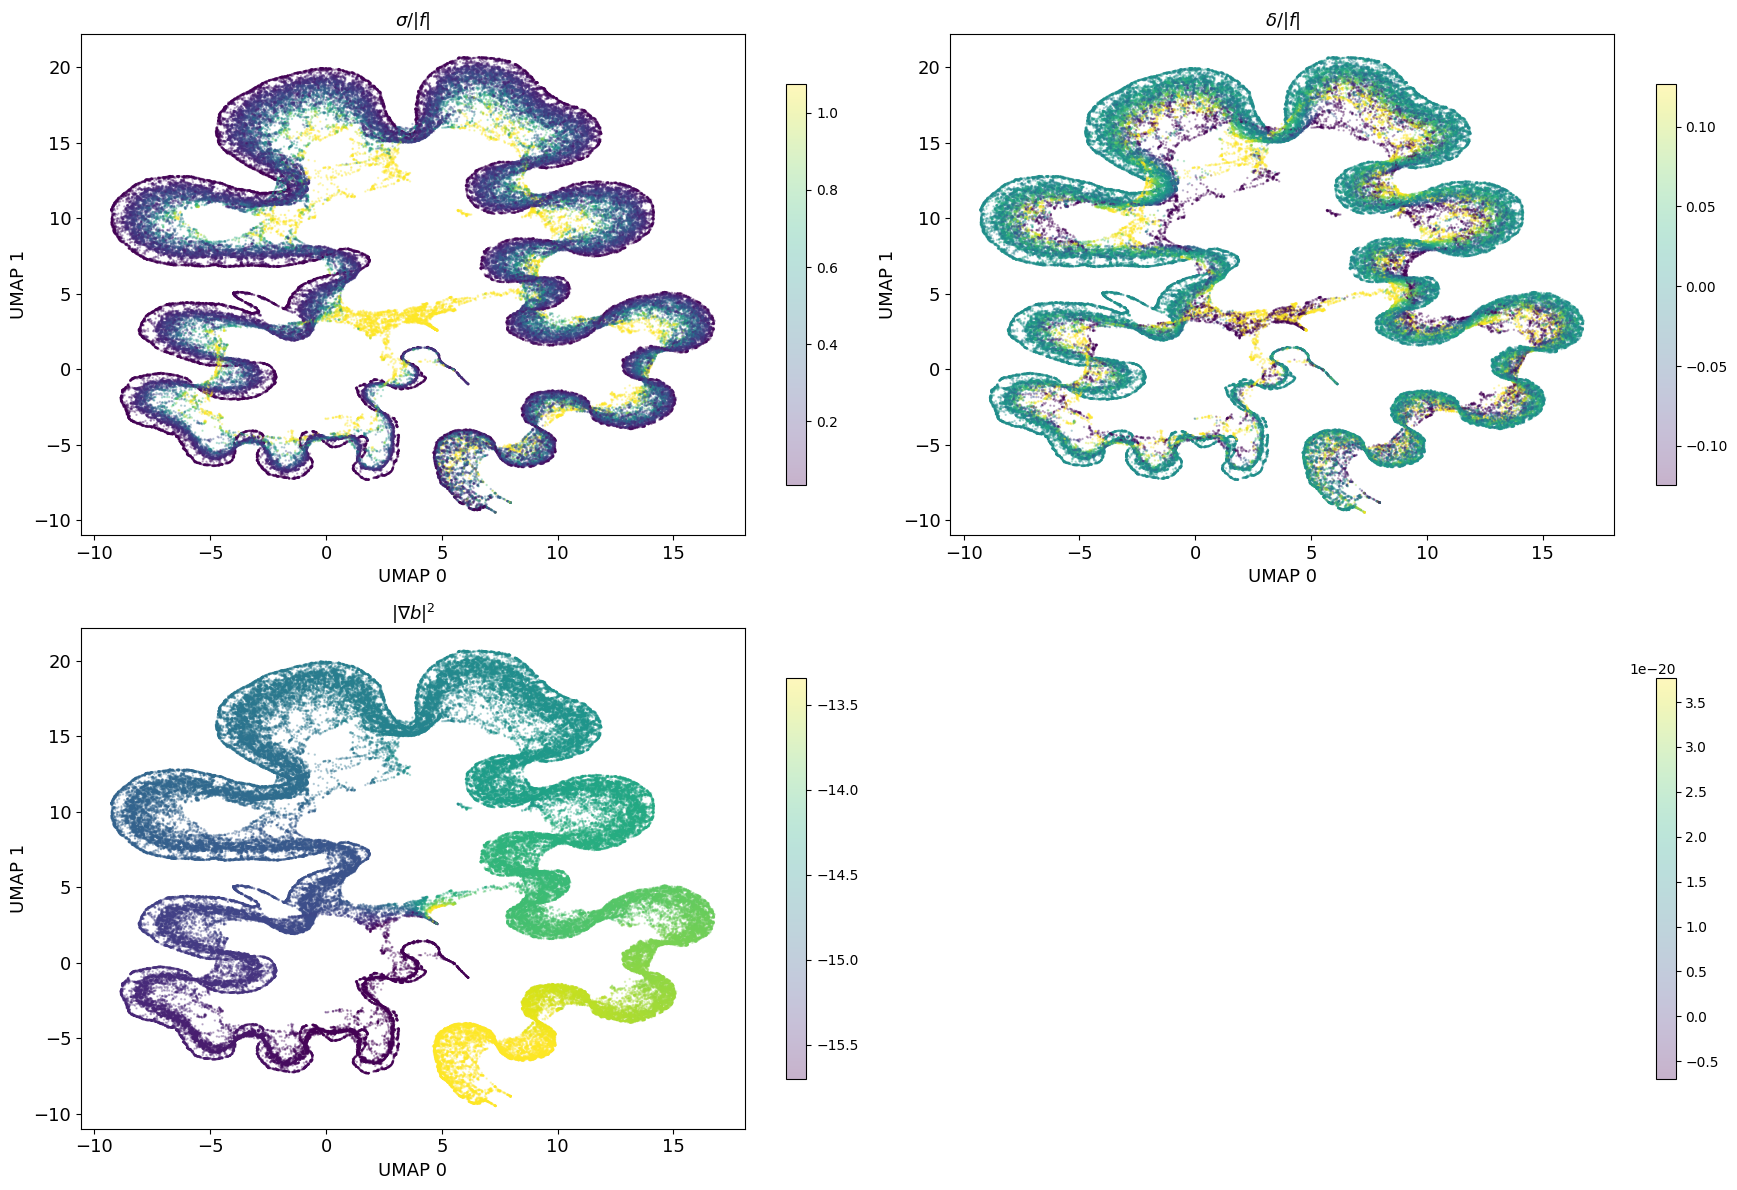

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

color_features = {
    #'npix': features['npix'].values,
    r'$\sigma / |f|$': features['strain_over_f'].values,
    r'$\delta / |f|$': features['divergence_over_f'].values,
    r'$|\nabla b|^2$': features['gradb2_median'].values,
    'Frontogenesis': features['frontogenesis_tendency_median'].values,
}

for i, (label, vals) in enumerate(color_features.items()):
    ax = axes[i]
    # Clip to 5th-95th percentile for better color contrast
    vmin, vmax = np.nanpercentile(vals, [5, 95])
    sc = ax.scatter(embedding[:, 0], embedding[:, 1], s=0.5, alpha=0.3,
                    c=vals, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_xlabel('UMAP 0')
    ax.set_ylabel('UMAP 1')
    ax.set_title(label)
    plt.colorbar(sc, ax=ax, shrink=0.8)
    plotting.set_fontsize(ax, 13.)

# Remove extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Density plot

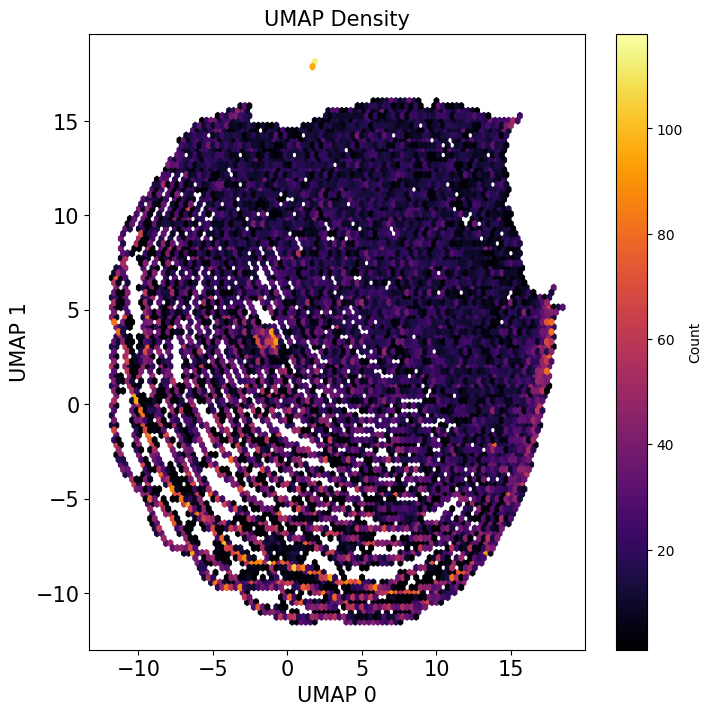

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
hb = ax.hexbin(embedding[:, 0], embedding[:, 1], gridsize=100,
               cmap='inferno', mincnt=1)
ax.set_xlabel('UMAP 0')
ax.set_ylabel('UMAP 1')
ax.set_title('UMAP Density')
plt.colorbar(hb, ax=ax, label='Count')
plotting.set_fontsize(ax, 15.)
plt.show()